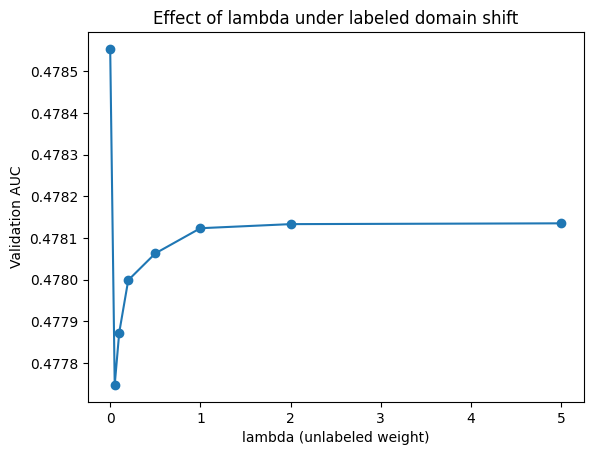

In [5]:
# Revised experiment to make lambda matter.
# Changes:
# 1) Make labeled sets SMALL and slightly BIASED (domain shift) relative to the true distribution.
# 2) Make classes overlap more (smaller mean gap, larger variances).
# 3) Keep unlabeled drawn from the TRUE mixture so it can help correct the labeled bias when lambda>0.
# 4) Evaluate AUC on validation drawn from the TRUE distribution.

import numpy as np
from numpy.linalg import slogdet, solve
from dataclasses import dataclass
import matplotlib.pyplot as plt
import pandas as pd

@dataclass
class GMMParams:
    pi: float
    mu0: np.ndarray
    mu1: np.ndarray
    Sigma0: np.ndarray
    Sigma1: np.ndarray

def _logpdf_mvn(X: np.ndarray, mu: np.ndarray, Sigma: np.ndarray) -> np.ndarray:
    d = X.shape[1]
    sign, logdet = slogdet(Sigma)
    if sign <= 0:
        raise np.linalg.LinAlgError("Covariance not PD (even after jitter).")
    Xc = X - mu
    A = solve(Sigma, Xc.T).T
    quad = np.einsum('ij,ij->i', Xc, A)
    return -0.5 * (d * np.log(2.0 * np.pi) + logdet + quad)

def _soft_counts(gamma: np.ndarray, N1: int, N0: int, lam: float, Nu: int):
    N1_tilde = N1 + lam * np.sum(gamma)
    N0_tilde = N0 + lam * np.sum(1.0 - gamma)
    N_tilde  = N1 + N0 + lam * Nu
    return N1_tilde, N0_tilde, N_tilde

def em_semisup_gmm(
    X_pos: np.ndarray,
    X_neg: np.ndarray,
    X_u:   np.ndarray,
    lam: float = 1.0,
    tol: float = 5e-6,
    max_iter: int = 200,
    eps_cov: float = 1e-6,
    resp_clip: float = 1e-6
) -> GMMParams:
    N1, d = X_pos.shape
    N0 = X_neg.shape[0]
    Nu = X_u.shape[0]

    mu1 = X_pos.mean(axis=0)
    mu0 = X_neg.mean(axis=0)
    S1  = np.cov(X_pos, rowvar=False) + eps_cov * np.eye(d)
    S0  = np.cov(X_neg, rowvar=False) + eps_cov * np.eye(d)
    pi  = N1 / (N1 + N0)

    for _ in range(max_iter):
        logp1 = _logpdf_mvn(X_u, mu1, S1) + np.log(np.clip(pi, 1e-12, 1-1e-12))
        logp0 = _logpdf_mvn(X_u, mu0, S0) + np.log(np.clip(1-pi, 1e-12, 1-1e-12))
        m = np.maximum(logp1, logp0)
        logden = m + np.log(np.exp(logp1 - m) + np.exp(logp0 - m))
        gamma = np.exp(logp1 - logden)
        gamma = np.clip(gamma, resp_clip, 1.0 - resp_clip)

        N1_tilde, N0_tilde, N_tilde = _soft_counts(gamma, N1, N0, lam, Nu)

        mu1_new = (X_pos.sum(axis=0) + lam * (gamma[:, None] * X_u).sum(axis=0)) / N1_tilde
        mu0_new = (X_neg.sum(axis=0) + lam * ((1.0 - gamma)[:, None] * X_u).sum(axis=0)) / N0_tilde

        Xp_c = X_pos - mu1_new
        Xu1  = X_u   - mu1_new
        S1_new = (Xp_c.T @ Xp_c + lam * (Xu1 * gamma[:, None]).T @ Xu1) / N1_tilde
        S1_new += eps_cov * np.eye(d)

        Xn_c = X_neg - mu0_new
        Xu0  = X_u   - mu0_new
        S0_new = (Xn_c.T @ Xn_c + lam * (Xu0 * (1.0 - gamma)[:, None]).T @ Xu0) / N0_tilde
        S0_new += eps_cov * np.eye(d)

        pi_new = N1_tilde / N_tilde

        delta = max(
            np.max(np.abs(mu1_new - mu1)),
            np.max(np.abs(mu0_new - mu0)),
            np.max(np.abs(S1_new - S1)),
            np.max(np.abs(S0_new - S0)),
            np.abs(pi_new - pi),
        )
        mu1, mu0, S1, S0, pi = mu1_new, mu0_new, S1_new, S0_new, pi_new
        if delta < tol:
            break

    return GMMParams(pi=pi, mu0=mu0, mu1=mu1, Sigma0=S0, Sigma1=S1)

def posterior_prob(x: np.ndarray, params: GMMParams) -> np.ndarray:
    logp1 = _logpdf_mvn(x, params.mu1, params.Sigma1) + np.log(np.clip(params.pi, 1e-12, 1-1e-12))
    logp0 = _logpdf_mvn(x, params.mu0, params.Sigma0) + np.log(np.clip(1-params.pi, 1e-12, 1-1e-12))
    m = np.maximum(logp1, logp0)
    den = m + np.log(np.exp(logp1 - m) + np.exp(logp0 - m))
    return np.exp(logp1 - den)

def make_psd_from_diag(diag_vals, rho=0.3):
    d = len(diag_vals)
    D = np.sqrt(np.outer(diag_vals, diag_vals))
    R = (1 - rho) * np.eye(d) + rho * np.ones((d, d))
    Sigma = D * R * D
    return Sigma

rng = np.random.default_rng(11)

# Dimensions & sizes
d = 10
N1_lab, N0_lab = 30, 30      # small labeled (biased)
Nu = 6000                    # lots of unlabeled
Nval = 4000                  # validation for eval

# True distribution (for unlabeled + validation)
mu0_true = np.linspace(0.20, 0.30, d)
mu1_true = mu0_true + 0.08   # modest separation
var0 = np.linspace(0.05, 0.025, d)
var1 = np.linspace(0.06, 0.03, d)  # slightly larger var for positives
Sigma0_true = make_psd_from_diag(var0, rho=0.25)
Sigma1_true = make_psd_from_diag(var1, rho=0.25)
pi_true = 0.35

def sample_class(n, mu, Sigma, rng):
    X = rng.multivariate_normal(mu, Sigma, size=n)
    return np.clip(X, 0.0, 1.0)

# Labeled domain shift: labeled come from shifted means (biased annotator features, etc.)
shift0 = -0.03 * np.ones(d)   # labeled negatives look *more negative*
shift1 = +0.03 * np.ones(d)   # labeled positives look *more positive*
mu0_lab = mu0_true + shift0
mu1_lab = mu1_true + shift1

X_pos = sample_class(N1_lab, mu1_lab, Sigma1_true, rng)
X_neg = sample_class(N0_lab, mu0_lab, Sigma0_true, rng)

# Unlabeled drawn from the TRUE mixture
z_u = rng.binomial(1, pi_true, size=Nu)
Xu_pos = sample_class(z_u.sum(), mu1_true, Sigma1_true, rng)
Xu_neg = sample_class((1 - z_u).sum(), mu0_true, Sigma0_true, rng)
X_u = np.vstack([Xu_pos, Xu_neg])[rng.permutation(Nu)]

# Validation drawn from TRUE distribution
z_val = rng.binomial(1, pi_true, size=Nval)
Xv_pos = sample_class(z_val.sum(), mu1_true, Sigma1_true, rng)
Xv_neg = sample_class((1 - z_val).sum(), mu0_true, Sigma0_true, rng)
X_val = np.vstack([Xv_pos, Xv_neg])[rng.permutation(Nval)]
y_val = np.hstack([np.ones(z_val.sum(), dtype=int), np.zeros((1 - z_val).sum(), dtype=int)])
y_val = y_val[np.random.permutation(Nval)]

def auc_roc(y_true, scores):
    y = np.asarray(y_true, dtype=float)
    s = np.asarray(scores, dtype=float)
    order = np.argsort(s)
    ranks = np.empty_like(order, dtype=float)
    ranks[order] = np.arange(len(s)) + 1.0
    n_pos = y.sum()
    n_neg = len(y) - n_pos
    sum_ranks_pos = ranks[y == 1].sum()
    U = sum_ranks_pos - n_pos * (n_pos + 1) / 2.0
    auc = U / (n_pos * n_neg)
    return auc

lambdas = [0.0, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0]
rows = []

for lam in lambdas:
    params = em_semisup_gmm(X_pos, X_neg, X_u, lam=lam, tol=1e-6, max_iter=400, eps_cov=1e-6, resp_clip=1e-6)
    scores = posterior_prob(X_val, params)
    auc = auc_roc(y_val, scores)
    mu0_err = np.linalg.norm(params.mu0 - mu0_true) / np.sqrt(d)
    mu1_err = np.linalg.norm(params.mu1 - mu1_true) / np.sqrt(d)
    rows.append({"lambda": lam, "AUC_val": float(auc), "pi_hat": float(params.pi),
                 "mu0_rms_err": float(mu0_err), "mu1_rms_err": float(mu1_err)})

res_df = pd.DataFrame(rows)
#from caas_jupyter_tools import display_dataframe_to_user
#display_dataframe_to_user("Lambda sweep with labeled domain shift", res_df)

plt.figure()
plt.plot(res_df["lambda"], res_df["AUC_val"], marker="o")
plt.xlabel("lambda (unlabeled weight)")
plt.ylabel("Validation AUC")
plt.title("Effect of lambda under labeled domain shift")
plt.show()
